AirBnB Data Analysis

In [2]:
import pandas as pd
listing = pd.read_csv('Listings.csv',
encoding = 'ISO-8859-1',
parse_dates = ['host_since'])

print(listing.info())

C:\Users\Rohit\AppData\Local\Temp\ipykernel_4972\745288202.py:2: DtypeWarning: Columns (0: host_response_time, 1: district) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv('Listings.csv',


<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  str           
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  str           
 11  host_identity_verified       279547 n

In [8]:
listing["host_since"] = pd.to_datetime(listing["host_since"])
print(listing.info())

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[us]
 4   host_location                278872 non-null  str           
 5   host_response_time           150930 non-null  str           
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  str           
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  str           
 11  host_identity_verified       279547 n

In [3]:
paris_listing = (
    listing
    [listing["city"].str.lower() == "paris"]
    .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)

paris_listing.info()

<class 'pandas.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[us]
 1   neighbourhood  64690 non-null  str           
 2   city           64690 non-null  str           
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 3.0 MB


In [4]:
paris_listing.isna().sum()
#paris_listing.isna().dropna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [5]:
paris_listing.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [6]:
paris_listing.query("price == 0 and accommodates == 0").count()
#paris_listing.query("price == 0 and accommodates == 0").dropna().count()

paris_listing.query("price == 0").count()
#paris_listing.query("price == 0").dropna().count()

host_since       62
neighbourhood    62
city             62
accommodates     62
price            62
dtype: int64

In [7]:
paris_listing_neighbourhood = (
    paris_listing
    .groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

paris_listing_neighbourhood.head()

,neighbourhood,price
0,Menilmontant,74.942257
1,Buttes-Chaumont,82.690182
2,Buttes-Montmartre,87.209479
3,Reuilly,89.058402
4,Popincourt,90.559459


In [8]:
most_expensive_neighbourhood = (
    paris_listing.groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

print(most_expensive_neighbourhood)

paris_listing_accommodations = (
    paris_listing[paris_listing['neighbourhood'] == most_expensive_neighbourhood]
    .groupby('accommodates')['price']
    .mean()
    .sort_values()
    )
paris_listing_accommodations.head()

Elysee


accommodates
0      0.000000
1     79.522222
3    152.828767
2    155.103352
4    212.096070
Name: price, dtype: float64

In [9]:
paris_listings_over_time = (
    paris_listing
    .groupby(paris_listing['host_since'].dt.year)
    .agg(
        average_price=('price', 'mean'),
        new_hosts_count=('host_since', 'count')
    )
)

paris_listings_over_time.head()

,average_price,new_hosts_count
host_since,,
2008.0,77.750000,4
2009.0,159.641509,106
2010.0,125.031250,416
2011.0,124.828230,1339
2012.0,111.578615,4592


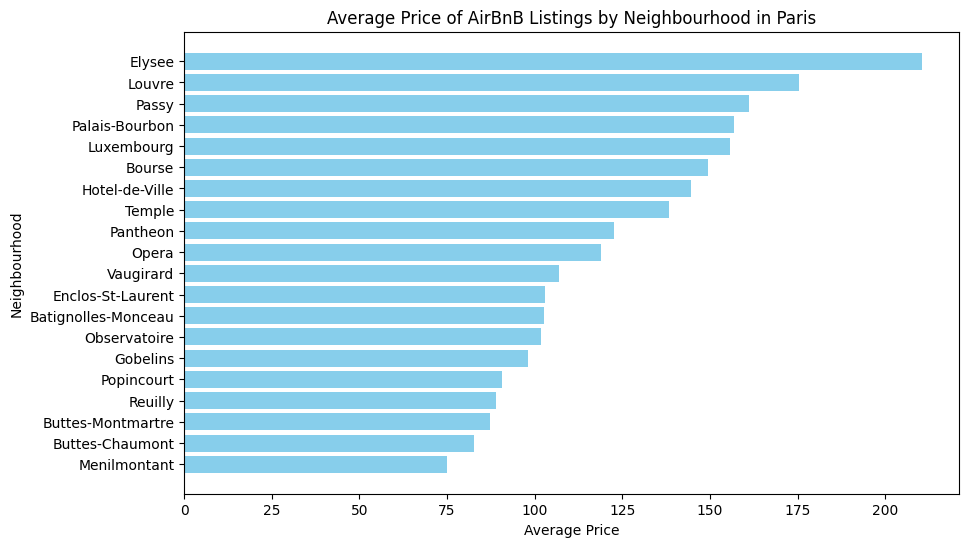

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(paris_listing_neighbourhood['neighbourhood'], paris_listing_neighbourhood['price'], color='skyblue')
plt.xlabel('Average Price')
plt.ylabel('Neighbourhood')
plt.title('Average Price of AirBnB Listings by Neighbourhood in Paris') 

plt.show()

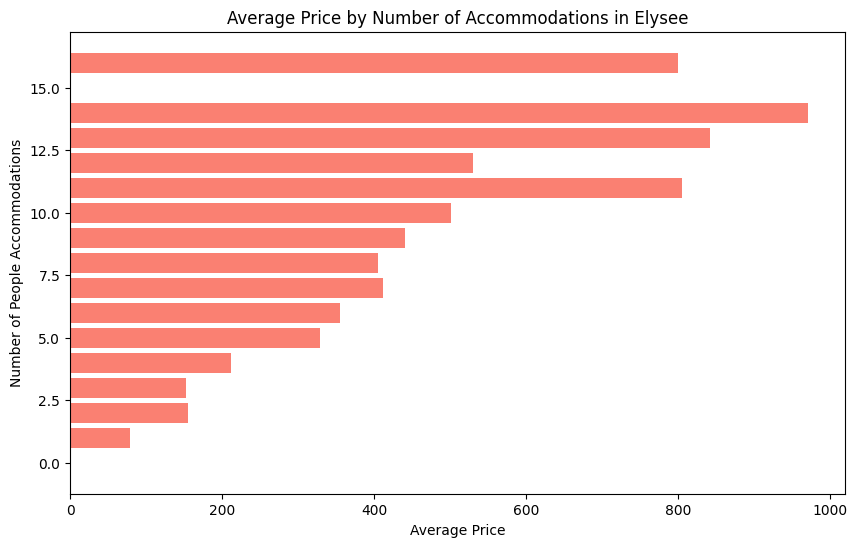

In [11]:
plt.figure(figsize=(10, 6))
plt.barh(paris_listing_accommodations.index, paris_listing_accommodations.values, color='salmon')
plt.xlabel('Average Price')
plt.ylabel('Number of People Accommodations')
plt.title(f'Average Price by Number of Accommodations in {most_expensive_neighbourhood}')

plt.show()

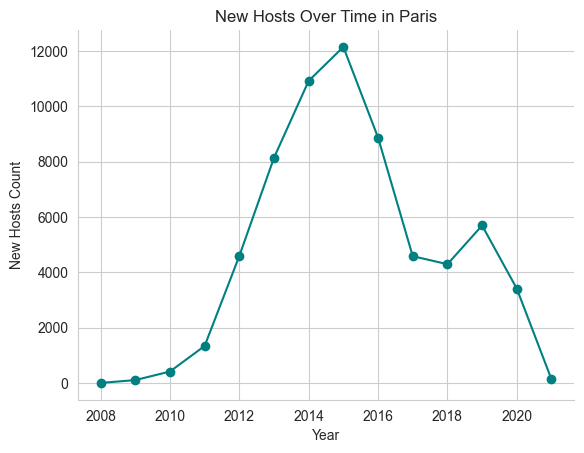

In [12]:
import seaborn as sns

sns.set_style("whitegrid")

paris_listings_over_time['new_hosts_count'].plot(
    kind='line',
    marker='o',
    color='teal'
)
plt.xlabel('Year')
plt.ylabel('New Hosts Count')
plt.title('New Hosts Over Time in Paris')
sns.despine()

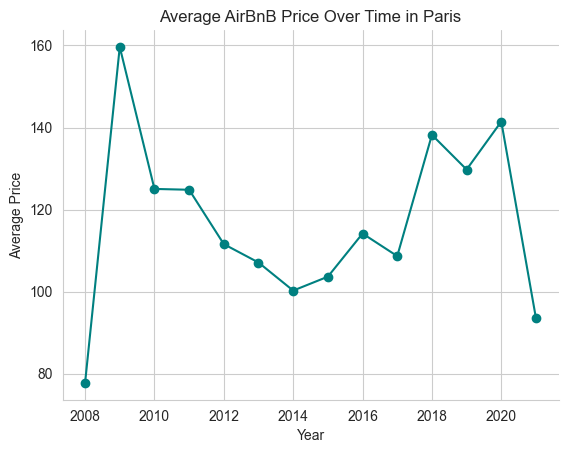

In [18]:
paris_listings_over_time['average_price'].plot(
    kind='line',
    marker='o',
    color='teal'
)
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.title('Average AirBnB Price Over Time in Paris')
sns.despine()

Text(0.5, 1.0, '2015 Regulation Impact on AirBnB in ParisFewer New Hosts, Higher Prices')

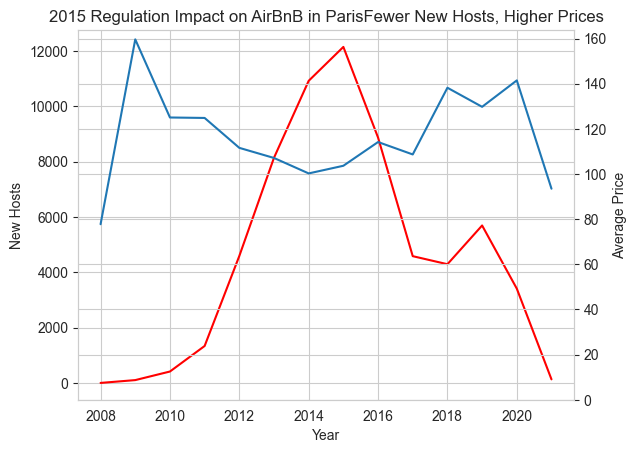

In [32]:
fig, ax = plt.subplots()

ax.plot(paris_listings_over_time.index, 
        paris_listings_over_time['new_hosts_count'],
        c = "Red"
)

plt.xlabel("Year")
plt.ylabel("New Hosts")

ax2 = plt.twinx()

ax2.plot(paris_listings_over_time.index, 
        paris_listings_over_time['average_price'],
)
ax2.set_ylim(0)

plt.ylabel("Average Price")
plt.title("2015 Regulation Impact on AirBnB in Paris" \
"Fewer New Hosts, Higher Prices")

In [ ]:
Paris Airbnb dataset (filtered to Paris) has:

- host_since, neighbourhood, city, accommodates, price.
- cleaned as datetime and filtered city == Paris.
- no major missingness shown.
- some listings have price == 0 / accommodates == 0 but few.

Analysis:

- average price per neighbourhood (low-to-high).
- most expensive neighbourhood identified.
- within that neighbourhood, average price by accommodates.
- yearly trend: average price and new hosts count from host_since.year.

Visuals:

- horizontal bar: avg price by neighbourhood.
- bar by accommodates in top neighbourhood.
- line plots: new hosts and avg price over years.
- combined dual-axis plot shows after 2015 regulation: fewer new hosts, higher prices.